In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import mgefit as mge
from astropy.io import fits
import sys

In [3]:
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')
import mge_ifu_merged as mg_help

# Load data

In [4]:
img_f200 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits')[0].data
dust_mask = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits')[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    dust_mask = dust_mask | nan_mask


Found 79853441 NaN pixels in the image. Replacing with 0 and adding to dust mask.


In [5]:
img = np.asarray(img_f200, dtype=float)
dust_mask_is_bad = True
if img.ndim != 2:
    raise ValueError("img_f200 must be a 2D array")

mask = np.asarray(dust_mask)
if mask.shape != img.shape:
    raise ValueError("dust_mask must have the same shape as img_f200")
if mask.dtype != bool:
    mask = mask.astype(bool)

goodmask = (~mask) if dust_mask_is_bad else mask

# Fill masked pixels for find_galaxy stability
img_for_find = img.copy()
fill = np.nanmedian(img[goodmask]) if np.any(goodmask) else np.nanmedian(img)
img_for_find[~goodmask] = fill
if not np.all(np.isfinite(img_for_find)):
    raise ValueError("Image contains NaN/Inf even after filling masked pixels")

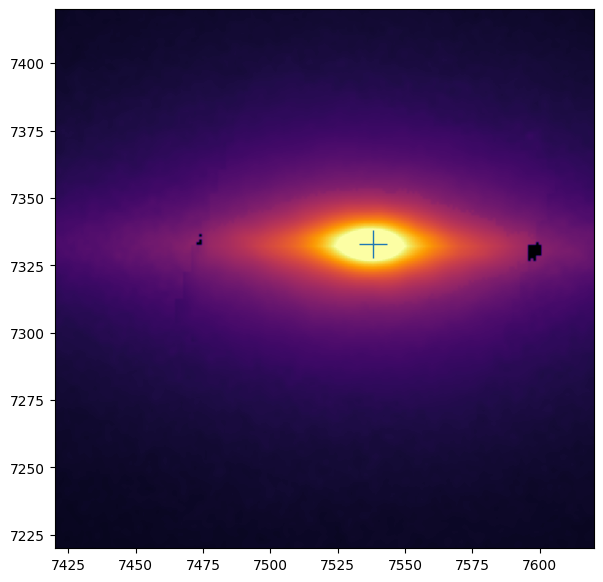

In [11]:
# plot img for find
fig, ax = plt.subplots(figsize=(10, 7))
zm_region = np.array(((7400, 7600), (7200, 7400))) + 20
im = ax.imshow(img_for_find, origin='lower', cmap='inferno',
                vmin=np.percentile(img_for_find, 0.1), vmax=np.percentile(img_for_find, 99.9999),
                # zoom into central region for better visualization
                #extent=(zm_region[0][0], zm_region[0][1], zm_region[1][0], zm_region[1][1])
                )
# mark the inital guess for center
ax.plot([7538], [7333],  marker='+', markersize = 20)
ax.set_xlim(zm_region[0][0], zm_region[0][1])
ax.set_ylim(zm_region[1][0], zm_region[1][1])
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import minimize

# ----------------------------
# Core utilities (fast + memory-light)
# ----------------------------
def cutout2d(img, x0, y0, half_size):
    """img[y, x]. Returns cutout and (x1, y1) origin in full-image pixels."""
    ny, nx = img.shape
    x0 = int(round(x0)); y0 = int(round(y0))
    x1 = max(0, x0 - half_size)
    x2 = min(nx, x0 + half_size + 1)
    y1 = max(0, y0 - half_size)
    y2 = min(ny, y0 + half_size + 1)
    return img[y1:y2, x1:x2], (x1, y1)

def robust_sky_from_border(cut, border=20):
    """Median of a border frame (robust background estimate)."""
    cut = np.asarray(cut)
    ny, nx = cut.shape
    b = int(min(border, ny//4, nx//4))
    if b < 2:
        return float(np.nanmedian(cut))
    top = cut[:b, :]; bot = cut[-b:, :]
    left = cut[:, :b]; right = cut[:, -b:]
    return float(np.nanmedian(np.concatenate([top.ravel(), bot.ravel(), left.ravel(), right.ravel()])))

def _rot(dx, dy, theta):
    c = np.cos(theta); s = np.sin(theta)
    xp = c*dx + s*dy
    yp = -s*dx + c*dy
    return xp, yp

def gaussian_base_vec(x, y, cx, cy, sx, sy, theta):
    dx = x - cx
    dy = y - cy
    xp, yp = _rot(dx, dy, theta)
    return np.exp(-0.5*((xp/sx)**2 + (yp/sy)**2))

def solve_amp_sky(d, b, w=None):
    """Fit d ≈ sky + amp*b (weighted), 2x2 analytic."""
    d = np.asarray(d, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if w is None:
        S1  = d.size
        Sb  = b.sum()
        Sbb = (b*b).sum()
        Sy  = d.sum()
        Sby = (b*d).sum()
    else:
        w = np.asarray(w, dtype=np.float64)
        S1  = w.sum()
        Sb  = (w*b).sum()
        Sbb = (w*b*b).sum()
        Sy  = (w*d).sum()
        Sby = (w*b*d).sum()

    det = S1*Sbb - Sb*Sb
    if det <= 0:
        sky = float(np.median(d))
        amp = float(np.max(d - sky))
        return amp, sky

    sky = (Sy*Sbb - Sb*Sby) / det
    amp = (S1*Sby - Sb*Sy) / det
    return float(amp), float(sky)

def moments_ellipse_fast(cut, sky=None, frac_keep=0.2):
    """
    Fast ellipse moments without building 2D coordinate grids.
    Uses weights w = max(cut - sky, 0), optionally keeping only top frac_keep of weights.
    Returns (x_mean, y_mean, theta_rad, q, sigma_major, sigma_minor, npix_used).
    """
    cut = np.asarray(cut, dtype=np.float64)
    ny, nx = cut.shape
    if sky is None:
        sky = robust_sky_from_border(cut)

    w = cut - sky
    w[~np.isfinite(w)] = 0.0
    w[w < 0] = 0.0

    if frac_keep is not None and 0 < frac_keep < 1:
        # keep only top weights to focus on galaxy, suppress noise/background
        flat = w.ravel()
        if flat.size > 0:
            thr = np.quantile(flat, 1 - frac_keep)
            w = np.where(w >= thr, w, 0.0)

    sw = w.sum()
    if sw <= 0:
        # fallback to cutout center
        x_mean = 0.5*(nx-1)
        y_mean = 0.5*(ny-1)
        return x_mean, y_mean, 0.0, 1.0, 1.0, 1.0, 0

    x = np.arange(nx, dtype=np.float64)
    y = np.arange(ny, dtype=np.float64)

    wx = w.sum(axis=0)  # length nx
    wy = w.sum(axis=1)  # length ny

    x_mean = (wx * x).sum() / sw
    y_mean = (wy * y).sum() / sw

    dx = x - x_mean
    dy = y - y_mean

    Ixx = (wx * dx*dx).sum() / sw
    Iyy = (wy * dy*dy).sum() / sw

    # Ixy = sum_y dy[y] * sum_x w[y,x] * dx[x] / sw
    sx_row = (w * dx[None, :]).sum(axis=1)
    Ixy = (sx_row * dy).sum() / sw

    # angle of major axis
    theta = 0.5*np.arctan2(2*Ixy, (Ixx - Iyy))

    # eigenvalues of covariance
    tr = Ixx + Iyy
    det = Ixx*Iyy - Ixy*Ixy
    disc = max(tr*tr - 4*det, 0.0)
    lam1 = 0.5*(tr + np.sqrt(disc))
    lam2 = 0.5*(tr - np.sqrt(disc))

    sigma_major = np.sqrt(max(lam1, 1e-12))
    sigma_minor = np.sqrt(max(lam2, 1e-12))

    # enforce major >= minor; rotate by 90 deg if swapped
    if sigma_minor > sigma_major:
        sigma_major, sigma_minor = sigma_minor, sigma_major
        theta += np.pi/2

    theta = (theta + np.pi/2) % np.pi - np.pi/2  # [-pi/2, pi/2)
    q = float(np.clip(sigma_minor / max(sigma_major, 1e-12), 1e-6, 1.0))
    npix = int(np.count_nonzero(w > 0))
    return float(x_mean), float(y_mean), float(theta), q, float(sigma_major), float(sigma_minor), npix

def astro_pa_from_theta(theta_rad):
    """
    If theta is measured from +x axis (to the right) in an image with y downward:
    an often-used 'astro PA' (from +y up, east of north) is approx: PA = 90 - theta_deg (mod 180).
    This matches your example (theta=0.8 -> PA=89.2).
    """
    theta_deg = np.degrees(theta_rad)
    pa = (90.0 - theta_deg) % 180.0
    return float(pa)

def inclination_from_q(q, q0=0.0):
    """cos^2 i = (q^2 - q0^2)/(1-q0^2), with q0 intrinsic thickness."""
    q = float(q)
    q0 = float(q0)
    if q0 < 0 or q0 >= 1:
        q0 = 0.0
    if q <= q0:
        return 90.0
    cos2i = (q*q - q0*q0) / (1.0 - q0*q0)
    cos2i = float(np.clip(cos2i, 0.0, 1.0))
    return float(np.degrees(np.arccos(np.sqrt(cos2i))))

def refine_center_small_gaussian(image, x_guess, y_guess, half=100,
                                 frac_keep=0.3,
                                 sx_init=12.0, sy_init=12.0,
                                 theta_init=0.0):
    """
    Constrained subpixel center in a small cutout.
    Fits only (cx, cy); (sx, sy, theta) fixed (core model), amp+sky analytic.
    """
    cut, (x1, y1) = cutout2d(image, x_guess, y_guess, half)
    cut = np.asarray(cut, dtype=np.float64)
    ny, nx = cut.shape

    sky0 = robust_sky_from_border(cut, border=max(5, half//5))

    # Focus on the core: keep top fraction of weights
    w = cut - sky0
    w[~np.isfinite(w)] = 0.0
    w[w < 0] = 0.0
    if frac_keep is not None and 0 < frac_keep < 1:
        thr = np.quantile(w.ravel(), 1 - frac_keep)
        mask = (w >= thr) & np.isfinite(cut)
    else:
        mask = np.isfinite(cut)

    # 1D vectors of x,y,data for speed
    yy, xx = np.nonzero(mask)
    d = cut[yy, xx]

    # initial guess in cutout coords
    cx0 = float(x_guess - x1)
    cy0 = float(y_guess - y1)

    # Bounds: center must lie inside this cutout
    bounds = [(0.0, nx - 1.0), (0.0, ny - 1.0)]

    def obj(p):
        cx, cy = p
        b = gaussian_base_vec(xx.astype(np.float64), yy.astype(np.float64),
                              cx, cy, sx_init, sy_init, theta_init)
        amp, sky = solve_amp_sky(d, b, w=None)
        r = d - (sky + amp*b)
        return float(np.dot(r, r))

    sol = minimize(obj, x0=np.array([cx0, cy0]), method="L-BFGS-B", bounds=bounds)
    cx, cy = sol.x

    out = {
        "x_cen": float(x1 + cx),
        "y_cen": float(y1 + cy),
        "cutout_origin": (int(x1), int(y1)),
        "cutout_shape": (int(ny), int(nx)),
        "success": bool(sol.success),
        "fun": float(sol.fun),
    }
    return out

def global_params_big_cutout(image, x_cen, y_cen, half=1000,
                             frac_keep=0.2, q0=0.0,
                             major_axis_kappa=4.0):
    """
    Compute peak, mean, theta, astro PA, eps, and a 'major axis scale' from moments.
    major_axis_kappa * sigma_major is a configurable "size" proxy.
    """
    cut, (x1, y1) = cutout2d(image, x_cen, y_cen, half)
    cut = np.asarray(cut, dtype=np.float64)
    ny, nx = cut.shape

    # peak pixel in this cutout
    jj, kk = np.unravel_index(np.nanargmax(cut), cut.shape)
    peak_y = int(y1 + jj)
    peak_x = int(x1 + kk)

    sky0 = robust_sky_from_border(cut, border=max(10, half//10))
    x_mean, y_mean, theta, q, smaj, smin, npix = moments_ellipse_fast(cut, sky=sky0, frac_keep=frac_keep)

    theta_deg = float(np.degrees(theta))
    astro_pa = astro_pa_from_theta(theta)
    eps = float(1.0 - q)
    incl = inclination_from_q(q, q0=q0)

    # "major axis" proxy from moment scale (tunable)
    major_axis_pix = float(major_axis_kappa * smaj)

    out = {
        "pixels_used": int(npix),
        "peak_yx": (peak_y, peak_x),  # (j,k) style: (y,x)
        "mean_yx": (float(y1 + y_mean), float(x1 + x_mean)),
        "theta_deg": theta_deg,
        "astro_pa_deg": astro_pa,
        "q": float(q),
        "eps": eps,
        "sigma_major_pix": float(smaj),
        "sigma_minor_pix": float(smin),
        "major_axis_pix": major_axis_pix,
        "inclination_deg": incl,
        "cutout_origin": (int(x1), int(y1)),
        "cutout_shape": (int(ny), int(nx)),
        "sky": float(sky0),
    }
    return out

# ----------------------------
# One-call pipeline
# ----------------------------
def center_then_shape(image, x_guess, y_guess,
                      half_center=100,
                      half_shape=1000,
                      # core gaussian "shape" used ONLY for center refinement:
                      core_sx=12.0, core_sy=12.0, core_theta_deg=0.0,
                      center_frac_keep=0.3,
                      shape_frac_keep=0.2,
                      q0=0.0,
                      major_axis_kappa=4.0):
    # Stage A
    c = refine_center_small_gaussian(
        image, x_guess, y_guess, half=half_center,
        frac_keep=center_frac_keep,
        sx_init=core_sx, sy_init=core_sy,
        theta_init=np.radians(core_theta_deg)
    )
    # Stage B
    g = global_params_big_cutout(
        image, c["x_cen"], c["y_cen"], half=half_shape,
        frac_keep=shape_frac_keep, q0=q0,
        major_axis_kappa=major_axis_kappa
    )
    return {"center": c, "global": g}



In [6]:
res = center_then_shape(
    img_for_find,
    x_guess=7538, y_guess=7333,
    half_center=100,     # hard constraint: true center must lie in this box
    half_shape=2000,     # for global params
    core_sx=10.0, core_sy=10.0, core_theta_deg=0.8,  # core model for center only
    center_frac_keep=0.3,
    shape_frac_keep=0.2,
    q0=0.0,
    major_axis_kappa=4.0
)

print(res["center"])
print(res["global"])

{'x_cen': 7537.219884279368, 'y_cen': 7332.548985227105, 'cutout_origin': (7438, 7233), 'cutout_shape': (201, 201), 'success': True, 'fun': 634828122.6442474}
{'pixels_used': 3201601, 'peak_yx': (7332, 7538), 'mean_yx': (7364.017702693088, 7532.88931445317), 'theta_deg': -0.7818587242987439, 'astro_pa_deg': 90.78185872429874, 'q': 0.2939043540079123, 'eps': 0.7060956459920877, 'sigma_major_pix': 737.4714742203379, 'sigma_minor_pix': 216.7460772299912, 'major_axis_pix': 2949.8858968813515, 'inclination_deg': 72.90815072586739, 'cutout_origin': (5537, 5333), 'cutout_shape': (4001, 4001), 'sky': 2.9966928958892822}
